Datos de Tomas-Statics.ods leídos y contados.
Datos de Misael-Statics.ods leídos y contados.
Datos de Camilo-Statics.ods leídos y contados.
Imagen guardada con éxito: Tomas-Categories.png


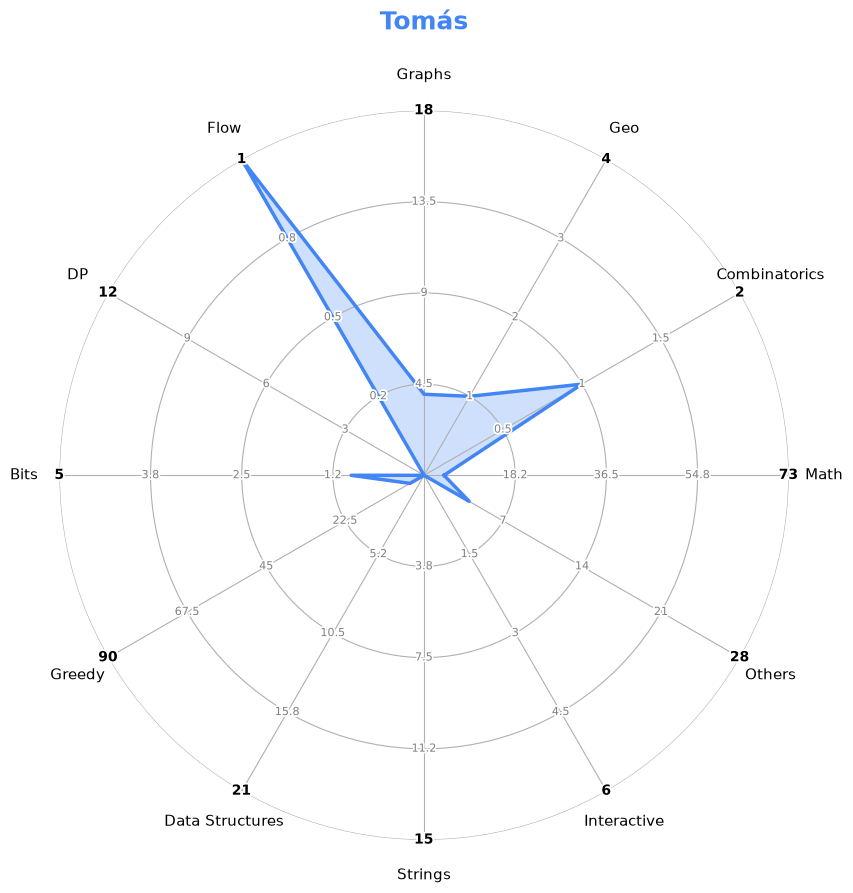

Imagen guardada con éxito: Misael-Categories.png


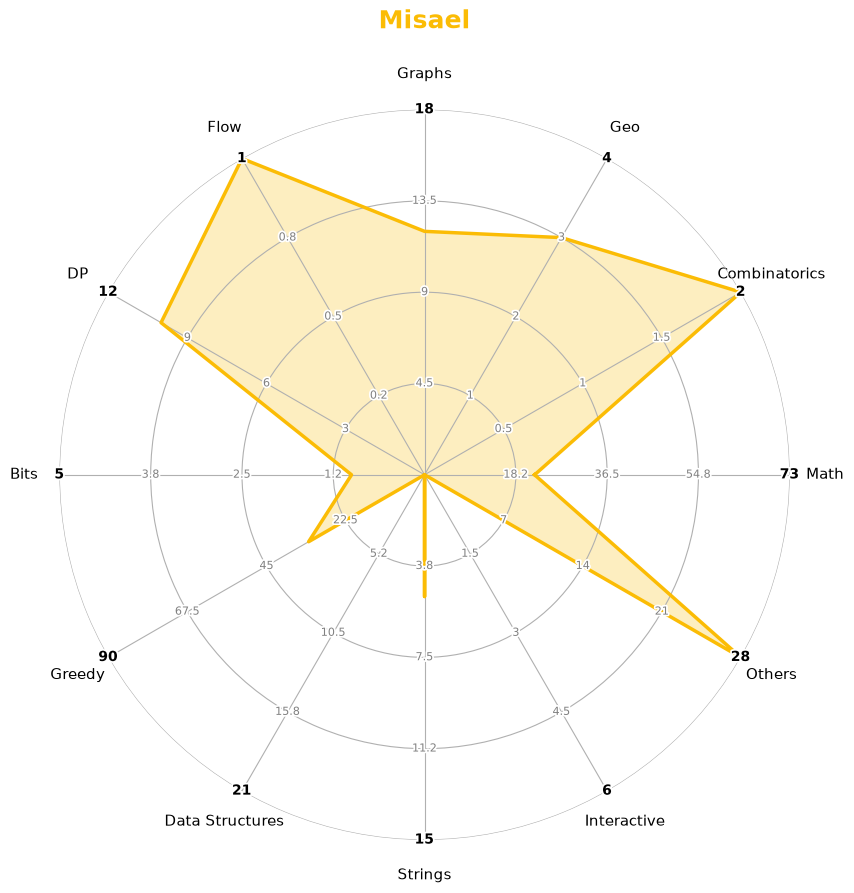

Imagen guardada con éxito: Camilo-Categories.png


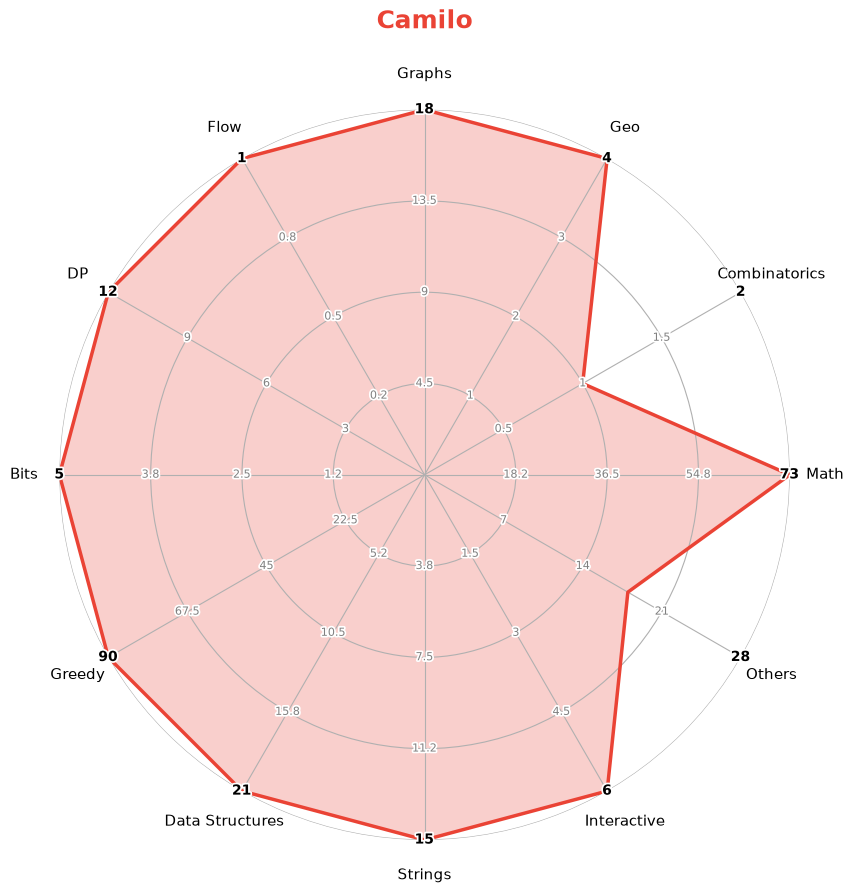

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from math import pi

# 1. Configuración de archivos y categorías
archivos = ['Tomas-Statics.ods', 'Misael-Statics.ods', 'Camilo-Statics.ods'] 
nombres = ['Tomás', 'Misael', 'Camilo']

categorias_validas = [
    "Math", "Combinatorics", "Geo", "Graphs", "Flow", "DP", "Bits",
    "Greedy", "Data Structures", "Strings", "Interactive", "Others"
]

# 2. Extracción de datos en crudo
datos_brutos = []
cat_lower_map = {cat.lower(): cat for cat in categorias_validas}

for archivo in archivos:
    try:
        df = pd.read_excel(archivo, engine='odf', dtype=object)
        col_cat = df.columns[1]
        df['categoria_limpia'] = df[col_cat].astype(str).str.lower().str.strip()
        df_filtrado = df[df['categoria_limpia'].isin(cat_lower_map.keys())]
        conteo = df_filtrado['categoria_limpia'].value_counts()
        valores = [conteo.get(cat.lower(), 0) for cat in categorias_validas]
        datos_brutos.append(valores)
        print(f"Datos de {archivo} leídos y contados.")
    except Exception as e:
        print(f"Aviso: No se procesaron datos en {archivo} -> {e}")
        datos_brutos.append([0] * len(categorias_validas))

datos_brutos = np.array(datos_brutos)

# 3. Normalización: Calcular el máximo por cada categoría
max_por_categoria = np.max(datos_brutos, axis=0)

datos_normalizados = []
for fila in datos_brutos:
    fila_norm = [val / mx if mx > 0 else 0 for val, mx in zip(fila, max_por_categoria)]
    datos_normalizados.append(fila_norm)

# 4. Configuración base del gráfico radial
N = len(categorias_validas)
angulos = [n / float(N) * 2 * pi for n in range(N)]
angulos += angulos[:1] 

colores = ['#4285F4', '#FBBC05', '#EA4335'] # Azul, Amarillo, Rojo

# 5. Dibujar UN gráfico por cada persona y guardarlo
for i in range(len(nombres)):
    fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))
    
    # Límite en 1.0 clavado para que los rayos no se escapen
    ax.set_ylim(0, 1.0) 
    
    # Empujamos los textos un poco hacia afuera
    ax.tick_params(axis='x', pad=15)
    
    # Hacemos invisible el borde exterior grueso
    ax.spines['polar'].set_visible(False)
    
    # Restauramos las 4 particiones
    fracciones = [0.25, 0.5, 0.75, 1.0]
    ax.set_yticks(fracciones)
    ax.set_yticklabels([]) 
    
    # Nombres de las categorías
    plt.xticks(angulos[:-1], categorias_validas, size=11)
    
    # Números limpios sin cajas
    for j, ang in enumerate(angulos[:-1]):
        max_val = max_por_categoria[j]
        if max_val > 0:
            for frac in fracciones:
                val = max_val * frac
                txt = f"{int(val)}" if float(val).is_integer() else f"{val:.1f}"
                
                peso = 'bold' if frac == 1.0 else 'normal'
                color_txt = 'black' if frac == 1.0 else 'gray'
                tam_txt = 10 if frac == 1.0 else 8
                
                ax.text(ang, frac, txt, color=color_txt, size=tam_txt,
                        ha='center', va='center', weight=peso, clip_on=False,
                        path_effects=[pe.withStroke(linewidth=2.5, foreground='white')])

    # Extraemos y cerramos los valores
    valores = datos_normalizados[i]
    valores_cerrados = valores + [valores[0]] 
    
    # Trazamos el polígono
    ax.plot(angulos, valores_cerrados, linewidth=2.5, linestyle='solid', color=colores[i])
    ax.fill(angulos, valores_cerrados, alpha=0.25, color=colores[i])
    
    # Detalles estéticos
    plt.title(nombres[i], size=18, y=1.1, fontweight='bold', color=colores[i])
    plt.tight_layout()
    
    # Limpiamos el nombre por si tiene tildes (ej. Tomás -> Tomas)
    nombre_limpio = nombres[i].replace('á', 'a').replace('é', 'e').replace('í', 'i').replace('ó', 'o').replace('ú', 'u')
    nombre_archivo = f"{nombre_limpio}-Categories.png"
    
    # Guardamos en alta calidad (dpi=300) antes de mostrar
    plt.savefig(nombre_archivo, dpi=300, bbox_inches='tight')
    print(f"Imagen guardada con éxito: {nombre_archivo}")
    
    # Mostramos
    plt.show()

Gráfico del equipo guardado como: Granola_Gaga-Categories.png


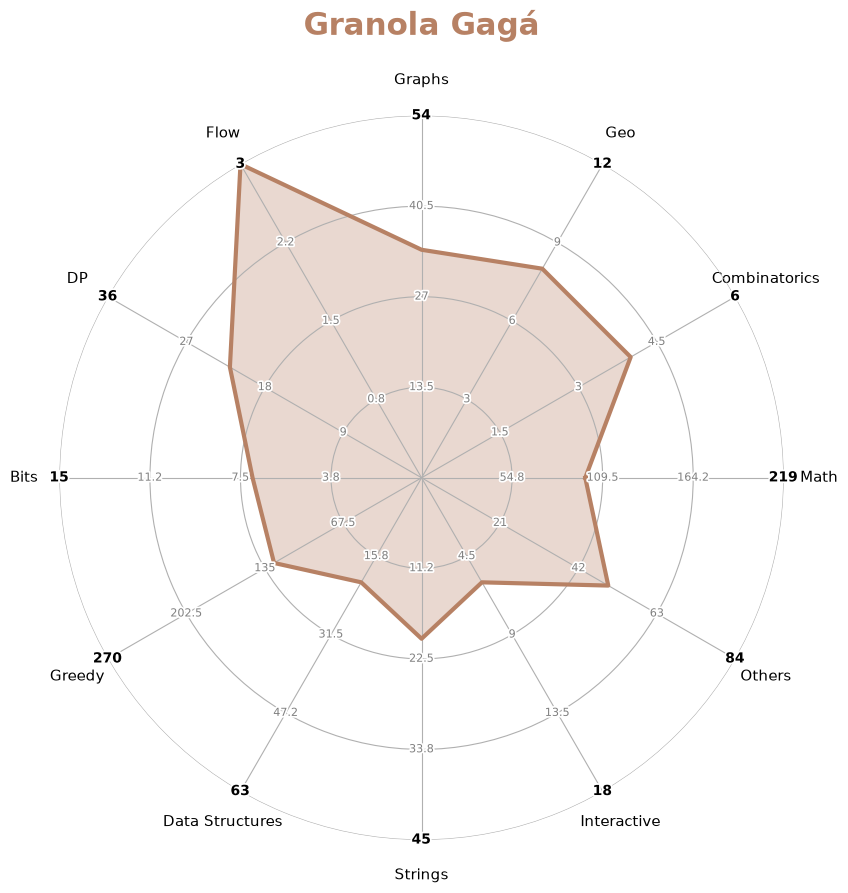

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from math import pi

# 1. Configuración
archivos = ['Tomas-Statics.ods', 'Misael-Statics.ods', 'Camilo-Statics.ods'] 
nombre_equipo = 'Granola Gagá'
color_equipo = '#B78164' # Mezcla exacta del Azul, Amarillo y Rojo

categorias_validas = [
    "Math", "Combinatorics", "Geo", "Graphs", "Flow", "DP", "Bits",
    "Greedy", "Data Structures", "Strings", "Interactive", "Others"
]

# 2. Extracción de datos en crudo
datos_brutos = []
cat_lower_map = {cat.lower(): cat for cat in categorias_validas}

for archivo in archivos:
    try:
        df = pd.read_excel(archivo, engine='odf', dtype=object)
        col_cat = df.columns[1]
        df['categoria_limpia'] = df[col_cat].astype(str).str.lower().str.strip()
        df_filtrado = df[df['categoria_limpia'].isin(cat_lower_map.keys())]
        conteo = df_filtrado['categoria_limpia'].value_counts()
        valores = [conteo.get(cat.lower(), 0) for cat in categorias_validas]
        datos_brutos.append(valores)
    except Exception as e:
        datos_brutos.append([0] * len(categorias_validas))

datos_brutos = np.array(datos_brutos)

# 3. Cálculos del equipo
# El máximo individual histórico de cada categoría
max_individual = np.max(datos_brutos, axis=0)

# El nuevo tope de la gráfica (máximo individual * 3)
max_equipo_eje = max_individual * 3

# La suma real de los problemas resueltos por todo el equipo
total_equipo = np.sum(datos_brutos, axis=0)

# Normalizamos de 0 a 1 en base al nuevo eje máximo
valores_norm = [val / mx if mx > 0 else 0 for val, mx in zip(total_equipo, max_equipo_eje)]

# 4. Configuración del gráfico radial
N = len(categorias_validas)
angulos = [n / float(N) * 2 * pi for n in range(N)]
angulos += angulos[:1] 

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))

ax.set_ylim(0, 1.0) 
ax.tick_params(axis='x', pad=15)
ax.spines['polar'].set_visible(False)

fracciones = [0.25, 0.5, 0.75, 1.0]
ax.set_yticks(fracciones)
ax.set_yticklabels([]) 
plt.xticks(angulos[:-1], categorias_validas, size=11)

# Números limpios en los ejes (basados en el tope del equipo)
for j, ang in enumerate(angulos[:-1]):
    max_val = max_equipo_eje[j]
    if max_val > 0:
        for frac in fracciones:
            val = max_val * frac
            txt = f"{int(val)}" if float(val).is_integer() else f"{val:.1f}"
            
            peso = 'bold' if frac == 1.0 else 'normal'
            color_txt = 'black' if frac == 1.0 else 'gray'
            tam_txt = 10 if frac == 1.0 else 8
            
            ax.text(ang, frac, txt, color=color_txt, size=tam_txt,
                    ha='center', va='center', weight=peso, clip_on=False,
                    path_effects=[pe.withStroke(linewidth=2.5, foreground='white')])

# 5. Dibujar la figura
valores_cerrados = valores_norm + [valores_norm[0]] 

ax.plot(angulos, valores_cerrados, linewidth=3, linestyle='solid', color=color_equipo)
ax.fill(angulos, valores_cerrados, alpha=0.3, color=color_equipo)

plt.title(nombre_equipo, size=22, y=1.1, fontweight='bold', color=color_equipo)
plt.tight_layout()

# Guardar la imagen limpiando los espacios y tildes
nombre_archivo = "Granola_Gaga-Categories.png"
plt.savefig(nombre_archivo, dpi=300, bbox_inches='tight')
print(f"Gráfico del equipo guardado como: {nombre_archivo}")

plt.show()

Gráfico guardado con éxito: Tomas-Submissions.png


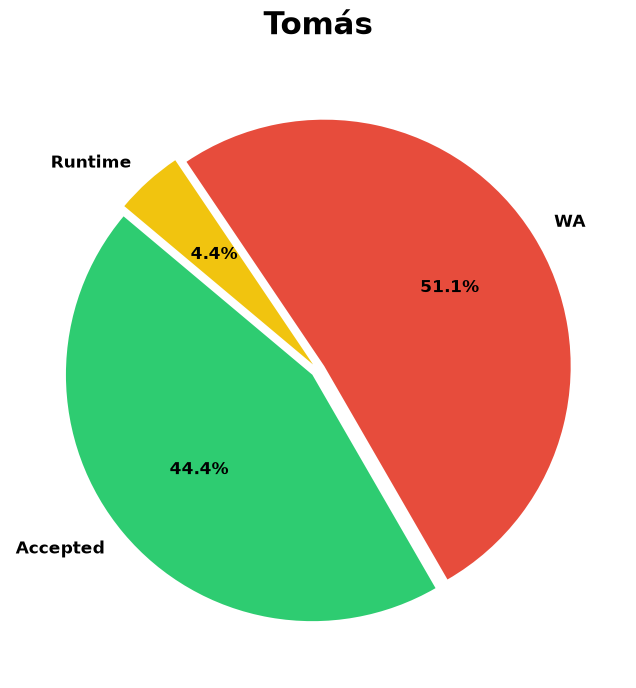

Gráfico guardado con éxito: Misael-Submissions.png


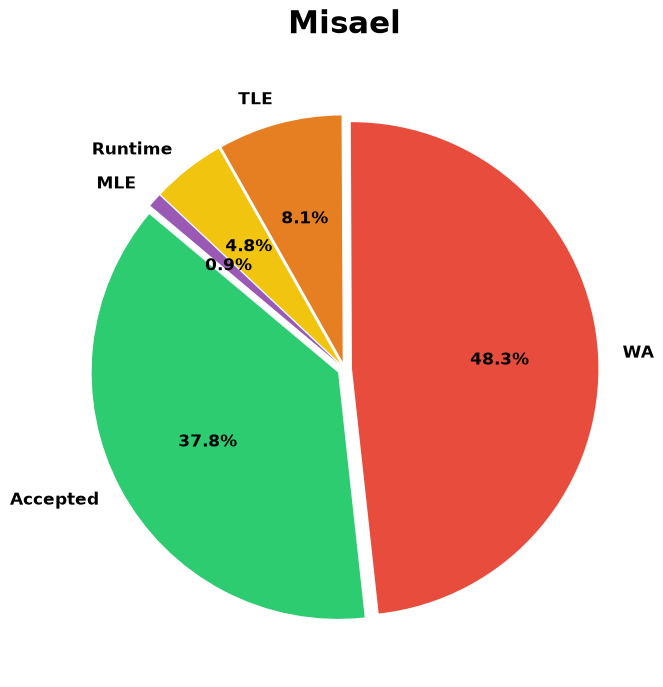

Gráfico guardado con éxito: Camilo-Submissions.png


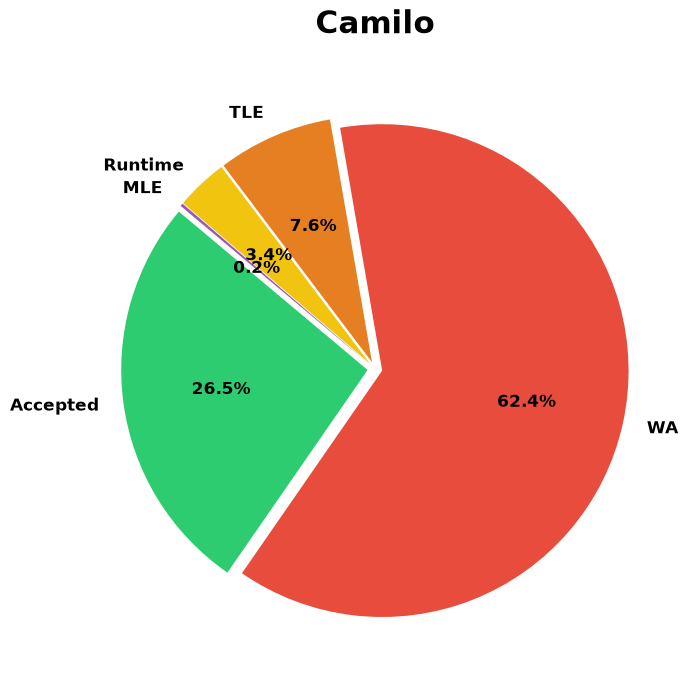

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Configuración
archivos = ['Tomas-Statics.ods', 'Misael-Statics.ods', 'Camilo-Statics.ods']
nombres = ['Tomás', 'Misael', 'Camilo']

# Paleta de colores estándar de Jueces Online (Codeforces, LeetCode, etc.)
etiquetas_base = ['Accepted', 'WA', 'TLE', 'Runtime', 'MLE']
colores_base = ['#2ecc71', '#e74c3c', '#e67e22', '#f1c40f', '#9b59b6']

# 2. Procesamiento y creación de los gráficos
for i, archivo in enumerate(archivos):
    try:
        # Leemos el archivo
        df = pd.read_excel(archivo, engine='odf')
        
        # Limpiamos las filas vacías basándonos en la primera columna (para no contar problemas fantasma)
        df = df.dropna(subset=[df.columns[0]])
        
        # Accepted: 1 punto por cada problema existente en la tabla
        accepted = len(df)
        
        # Para evitar errores por mayúsculas/minúsculas en tu Excel, estandarizamos las columnas
        columnas_df = [str(c).upper().strip() for c in df.columns]
        df.columns = columnas_df
        
        # Sumamos los errores (si la columna no existe o está vacía, suma 0)
        wa = pd.to_numeric(df['WA'], errors='coerce').sum() if 'WA' in columnas_df else 0
        tle = pd.to_numeric(df['TLE'], errors='coerce').sum() if 'TLE' in columnas_df else 0
        runtime = pd.to_numeric(df['RUNTIME'], errors='coerce').sum() if 'RUNTIME' in columnas_df else 0
        mle = pd.to_numeric(df['MLE'], errors='coerce').sum() if 'MLE' in columnas_df else 0
        
        valores = [accepted, wa, tle, runtime, mle]
        
        # 3. Filtrar ceros (Para que el gráfico se dibuje limpio solo con los errores que sí cometieron)
        valores_grafico = []
        etiquetas_grafico = []
        colores_grafico = []
        
        for val, etiq, col in zip(valores, etiquetas_base, colores_base):
            if val > 0:
                valores_grafico.append(val)
                etiquetas_grafico.append(etiq)
                colores_grafico.append(col)
                
        # 4. Dibujar el gráfico de torta
        fig, ax = plt.subplots(figsize=(8, 8))
        
        # Generamos la torta con porcentajes a 1 decimal y separamos apenas las porciones (explode) para más estética
        explode = [0.03] * len(valores_grafico) 
        ax.pie(valores_grafico, labels=etiquetas_grafico, colors=colores_grafico, 
               autopct='%1.1f%%', startangle=140, explode=explode,
               textprops={'fontsize': 12, 'weight': 'bold'}, 
               shadow=False)
        
        # Título con el nombre
        plt.title(nombres[i], size=22, fontweight='bold', pad=20)
        
        # 5. Guardar la imagen localmente
        nombre_limpio = nombres[i].replace('á', 'a').replace('é', 'e').replace('í', 'i').replace('ó', 'o').replace('ú', 'u')
        nombre_archivo = f"{nombre_limpio}-Submissions.png"
        plt.savefig(nombre_archivo, dpi=300, bbox_inches='tight')
        
        print(f"Gráfico guardado con éxito: {nombre_archivo}")
        
        # Mostramos en pantalla
        plt.show()
        
    except Exception as e:
        print(f"Aviso: Hubo un problema al procesar los submissions de {archivo} -> {e}")

Gráfico del equipo guardado con éxito: Granola_Gaga-Submissions.png


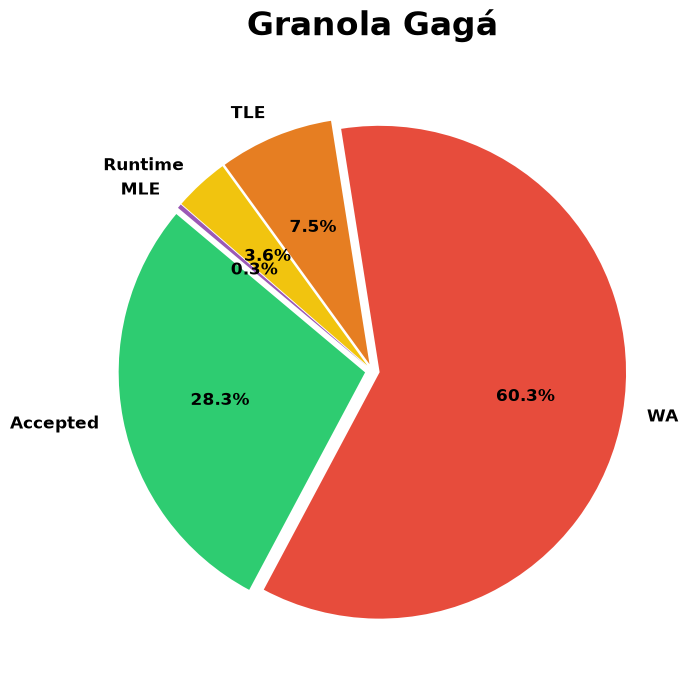

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Configuración
archivos = ['Tomas-Statics.ods', 'Misael-Statics.ods', 'Camilo-Statics.ods']
nombre_equipo = 'Granola Gagá'

# Paleta de colores estándar
etiquetas_base = ['Accepted', 'WA', 'TLE', 'Runtime', 'MLE']
colores_base = ['#2ecc71', '#e74c3c', '#e67e22', '#f1c40f', '#9b59b6']

# Contadores globales del equipo
total_accepted = 0
total_wa = 0
total_tle = 0
total_runtime = 0
total_mle = 0

# 2. Procesamiento de todas las tablas y sumatoria
for archivo in archivos:
    try:
        df = pd.read_excel(archivo, engine='odf')
        # Limpiamos filas vacías basándonos en la primera columna
        df = df.dropna(subset=[df.columns[0]])
        
        # Sumamos los problemas totales del archivo al "Accepted" del equipo
        total_accepted += len(df)
        
        columnas_df = [str(c).upper().strip() for c in df.columns]
        df.columns = columnas_df
        
        # Acumulamos los errores
        total_wa += pd.to_numeric(df['WA'], errors='coerce').sum() if 'WA' in columnas_df else 0
        total_tle += pd.to_numeric(df['TLE'], errors='coerce').sum() if 'TLE' in columnas_df else 0
        total_runtime += pd.to_numeric(df['RUNTIME'], errors='coerce').sum() if 'RUNTIME' in columnas_df else 0
        total_mle += pd.to_numeric(df['MLE'], errors='coerce').sum() if 'MLE' in columnas_df else 0
        
    except Exception as e:
        print(f"Aviso: Hubo un problema al leer {archivo} -> {e}")

# 3. Preparar datos para el gráfico (Filtrar ceros)
valores = [total_accepted, total_wa, total_tle, total_runtime, total_mle]
valores_grafico = []
etiquetas_grafico = []
colores_grafico = []

for val, etiq, col in zip(valores, etiquetas_base, colores_base):
    if val > 0:
        valores_grafico.append(val)
        etiquetas_grafico.append(etiq)
        colores_grafico.append(col)

# 4. Dibujar el gráfico de torta del equipo
if sum(valores_grafico) > 0:
    fig, ax = plt.subplots(figsize=(8, 8))
    
    # Generamos la torta separando apenas las porciones
    explode = [0.03] * len(valores_grafico) 
    ax.pie(valores_grafico, labels=etiquetas_grafico, colors=colores_grafico, 
           autopct='%1.1f%%', startangle=140, explode=explode,
           textprops={'fontsize': 12, 'weight': 'bold'}, 
           shadow=False)
    
    # Título con el nombre en NEGRO
    plt.title(nombre_equipo, size=24, fontweight='bold', pad=20, color='black')
    
    # 5. Guardar la imagen localmente
    nombre_archivo = "Granola_Gaga-Submissions.png"
    plt.savefig(nombre_archivo, dpi=300, bbox_inches='tight')
    
    print(f"Gráfico del equipo guardado con éxito: {nombre_archivo}")
    plt.show()
else:
    print("No hay datos para graficar. Asegurate de que los archivos tengan registros.")

In [5]:
import pandas as pd

# Lista de los integrantes basada en la salida de tu celda anterior
integrantes = ["Tomas", "Misael", "Camilo"]

print("--- Promedio de Dificultad por Integrante ---")

for integrante in integrantes:
    archivo = f"{integrante}-Statics.ods"
    try:
        # Leer el archivo .ods de cada integrante
        df = pd.read_excel(archivo, engine="odf")
        
        # Calcular el promedio de la columna 'Dificultad'
        promedio = df['Dificultad'].mean()
        
        # Imprimir el resultado con dos decimales
        print(f"{integrante}: {promedio:.2f}")
        
    except KeyError:
        print(f"{integrante}: Error - No se encontró la columna 'Dificultad' en el archivo.")
    except Exception as e:
        print(f"{integrante}: Error al procesar el archivo ({e})")

--- Promedio de Dificultad por Integrante ---
Tomas: nan
Misael: 1050.00
Camilo: 1145.35
